# 4. Predictive Modeling of Diabetes Risk

## Overview

This notebook develops and evaluates a predictive model to identify individuals at elevated risk for diabetes using demographic, behavioral and health-related indicators derived from the BRFSS dataset.

Building on the cleaned and harmonized dataset prepared in earlier steps, this stage applies machine learning techniques to quantify how multiple risk factors collectively influence diabetes risk.

## Modeling Objectives

The modeling process aims to:

- develop a robust predictive model for diabetes risk classification  
- address class imbalance to improve detection of diabetes cases  
- evaluate predictive performance using health-relevant metrics  
- identify key risk drivers through model interpretability techniques  

## Methodological Approach

Extreme Gradient Boosting (XGBoost) is employed due to its strong performance with structured health data and its ability to model nonlinear relationships and interactions among predictors. Class imbalance techniques are applied to improve sensitivity to diabetes cases and SHAP (Shapley Additive Explanations) is used to enhance transparency by quantifying the contribution of individual predictors.

## Research Relevance

Predictive modeling supports the study’s objective of understanding diabetes risk patterns and identifying high-risk populations. By combining predictive accuracy with interpretability, the modeling approach provides insights that can inform prevention strategies and public health decision-making.


## 4.1  Import Required Libraries

In [18]:
from pathlib import Path
from typing import Union
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve, auc

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping

import shap
import matplotlib.pyplot as plt
import warnings
import logging


warnings.filterwarnings("ignore")

# Plotting style
plt.style.use("seaborn-v0_8-darkgrid")

# Configure Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

## 4.2 Configuration and File Paths

In [19]:
# Use pathlib for robust path handling
BASE_DIR = Path.cwd().parent 
PROCESSED_DATA_DIR = BASE_DIR / "data_processed"
REPORTS_DIR = BASE_DIR / "reports"
MODELS_DIR = BASE_DIR / "models"
CONFIG_DIR = BASE_DIR / "config"
BRFSS_HARMONIZED_CLEAN_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024_cleaned.zip"
RECODED_CONFIG_FILE = CONFIG_DIR / "VALUE_RECODED_TEXT_MAP.json"

# Ensure directories exist where the processed data will be saved
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 4.3 Utility Functions

In [20]:
def read_zipped_csv(
    zip_path: Union[str, Path],
    **read_csv_kwargs
) -> pd.DataFrame:
    """
    Read a single-CSV .zip file into a pandas DataFrame.

    Parameters
    ----------
    zip_path : str or Path
        Path to the .zip file (containing exactly one CSV, or a CSV
        with the same name as the zip).
    **read_csv_kwargs :
        Any extra keyword args passed through to pandas.read_csv
        (e.g. sep, dtype, parse_dates).

    Returns
    -------
    pd.DataFrame
    """
    zip_path = Path(zip_path)
    # For a single CSV in the zip, this is enough:
    return pd.read_csv(zip_path, compression="zip", **read_csv_kwargs)

## 4.4 Load Dataset

In [21]:
df_raw = read_zipped_csv(BRFSS_HARMONIZED_CLEAN_ZIP_FILE)
logging.info(f"Initial data loaded with {df_raw.shape[0]} rows. and columns: {df_raw.shape[1]}")

2026-02-18 23:31:08 - INFO - Initial data loaded with 3101950 rows. and columns: 27


In [22]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3101950 entries, 0 to 3101949
Data columns (total 27 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   YEAR                       int64  
 1   DIABETES                   float64
 2   AGE_CATEGORIES             int64  
 3   SEX                        float64
 4   RACE                       float64
 5   INCOME                     float64
 6   EDUCATION_LEVEL            int64  
 7   EMPLOYMENT                 float64
 8   MARITAL_STATUS             float64
 9   HEALTH_CARE_COVERAGE       float64
 10  BMICAT                     float64
 11  HEART_ATTACK               float64
 12  STROKE                     float64
 13  EXERCISE                   int64  
 14  SMOKER                     int64  
 15  HEAVY_ALCOHOL_CONSUMPTION  float64
 16  HEALTH_STATUS              int64  
 17  POOR_PHYSICAL_HEALTH_DAYS  int64  
 18  POOR_MENTAL_HEALTH_DAYS    int64  
 19  PRE_DIABETES               int64  
 20  GE

## 4.5 Feature Selection

In [23]:
# Select all columns except the target and some related features
features = [col for col in df_raw.columns if col not in ["YEAR", "DIABETES", "IS_YOUNG_ADULT", "PANDEMIC_FLAG", "RISK_OBESITY", "RISK_INACTIVE", "RISK_SMOKING"]]
target = "DIABETES"

X = df_raw[features]
y = df_raw[target]

## 4.6 Train Test Split

### Training and Testing Strategy

The dataset is partitioned into training, testing and validation subsets to evaluate model generalization. This approach ensures that performance metrics reflect the model’s ability to predict diabetes risk for unseen individuals.

In [24]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=RANDOM_STATE, stratify=y_trainval)

logging.info(f"Training set: {X_train.shape[0]} samples, Validation set: {X_val.shape[0]} samples, Testing set: {X_test.shape[0]} samples")

2026-02-18 23:31:12 - INFO - Training set: 1985248 samples, Validation set: 496312 samples, Testing set: 620390 samples


## 4.7 Handle Class Imbalance (SMOTE)

## Handling Class Imbalance

Diabetes cases represent a minority of observations. Without adjustment, predictive models may favor the majority class, leading to under-detection of high-risk individuals.

Synthetic Minority Over-sampling Technique (SMOTE) is applied to the training data to improve sensitivity to diabetes cases and enhance the model’s practical utility for risk identification.

In [25]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

logging.info(f"Before SMOTE: {y_train.value_counts()}")
logging.info(f"After SMOTE: {y_train_balanced.value_counts()}")

2026-02-18 23:32:34 - INFO - Before SMOTE: DIABETES
0.0    1642539
1.0     342709
Name: count, dtype: int64
2026-02-18 23:32:34 - INFO - After SMOTE: DIABETES
0.0    1642539
1.0    1642539
Name: count, dtype: int64


There is a practical disbalance because there are many more non-cases than actual positive cases. The model training on this distribution will create predictions that favor the majority class which results in an accurate model appearance but fails to identify many diabetes-positive individuals. The training dataset needed SMOTE application to create synthetic diabetes case data which produced authentic diabetes cases from existing minority study data.

The model used data balancing to achieve improved results because it could now detect diabetes more effectively by identifying at-risk individuals instead of predicting the common "non-diabetic" outcome. This results in improved recall which establishes a clear decision boundary between different risk groups. The SMOTE application restricted itself to the training set which allows the evaluation results to demonstrate actual world disease distribution.

The model gains practical public health value through this adjustment because it helps better identify individuals needing early treatment while avoiding all missed cases caused by class imbalance.

## 4.8 Train XGBOOST Model

## Model Selection Rationale

Extreme Gradient Boosting (XGBoost) was selected due to its strong performance with structured data, ability to capture nonlinear relationships and robustness to multicollinearity. These characteristics make it well suited for modeling complex interactions among demographic, behavioral and health-related predictors.

GPU acceleration is utilized to efficiently process large survey datasets.

In [26]:
early_stop = EarlyStopping(rounds=10, metric_name="logloss", data_name="validation_0", save_best=True)

model = XGBClassifier(
    tree_method="gpu_hist",        # GPU training
    predictor="gpu_predictor",     # GPU prediction
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    callbacks=[early_stop]
)

model.fit(X_train_balanced, y_train_balanced, eval_set=[(X_val, y_val)], verbose=False)
logging.info("Model training completed.")

model.save_model(MODELS_DIR / "xgb_diabetes_model.json")
logging.info(f"Model saved to {MODELS_DIR / 'xgb_diabetes_model.json'}")

2026-02-18 23:32:46 - INFO - Model training completed.
2026-02-18 23:32:46 - INFO - Model saved to c:\github\brfss-diabetes-trends\models\xgb_diabetes_model.json


## 4.9 Model Evaluation

## Model Evaluation Strategy

Model performance is evaluated using accuracy, precision, recall and F1-score. Recall is particularly important in a public health context because failing to identify individuals at risk for diabetes may delay early intervention.

The F1-score balances precision and recall, providing a comprehensive measure of predictive performance.

In [27]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

logging.info(f"\n{classification_report(y_test, y_pred)}")

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

logging.info(f"PR-AUC: {pr_auc}")

2026-02-18 23:32:48 - INFO - 
              precision    recall  f1-score   support

         0.0       0.90      0.80      0.85    513293
         1.0       0.38      0.57      0.45    107097

    accuracy                           0.76    620390
   macro avg       0.64      0.69      0.65    620390
weighted avg       0.81      0.76      0.78    620390

2026-02-18 23:32:48 - INFO - PR-AUC: 0.39890401930216035


These performance results indicate the model is effective in identifying high-risk individuals while maintaining balanced predictive accuracy.

## 4.10  Feature Importance

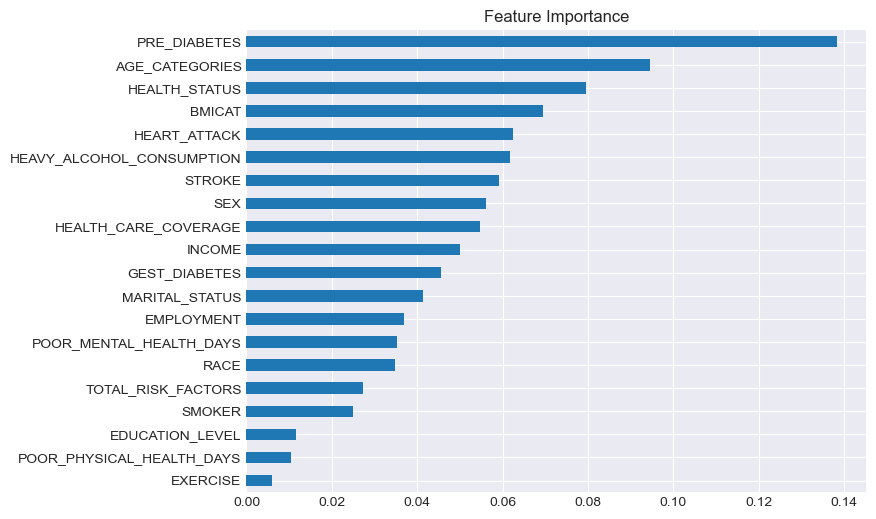

In [28]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

The above feature importance plot demonstrates that `diabetes` prevalence arises from metabolic and clinical conditions instead of short-term behavior patterns. The strongest predictive power comes from `pre-diabetes` status because it functions as an early warning indicator. Cardiovascular history together with overall health status, age, sex and BMI values shows strong effects because these factors create a direct relationship between metabolic health and vascular disease development.

Moderate predictive power arises from healthcare coverage, income and socioeconomic factors while smoking and heavy alcohol use behavioral risks create additional risk factors. The composite risk index demonstrates cumulative risk principles through its structure while education level and exercise create minimal direct effects. The model establishes diabetes as a complex condition which develops through both clinical health status and structural environmental factors.

## 4.11 SHAP Explainability

## Model Interpretability

Understanding why the model makes predictions is essential in health research. SHAP (Shapley Additive Explanations) is used to quantify the contribution of each predictor to diabetes risk.

This approach enhances transparency, supports clinical interpretation and ensures that findings can inform public health decision-making.

In [29]:
# convert to float32 for performance & memory efficiency
X_train_balanced = X_train_balanced.astype("float32")
X_test = X_test.astype("float32")

# sample background data (improves SHAP speed)
background = shap.sample(X_train_balanced, 200, random_state=RANDOM_STATE)

# sample test set if large
if len(X_test) > 5000:
    X_test_sample = shap.sample(X_test, 5000, random_state=RANDOM_STATE)
else:
    X_test_sample = X_test

 99%|===================| 4957/5000 [00:41<00:00]        

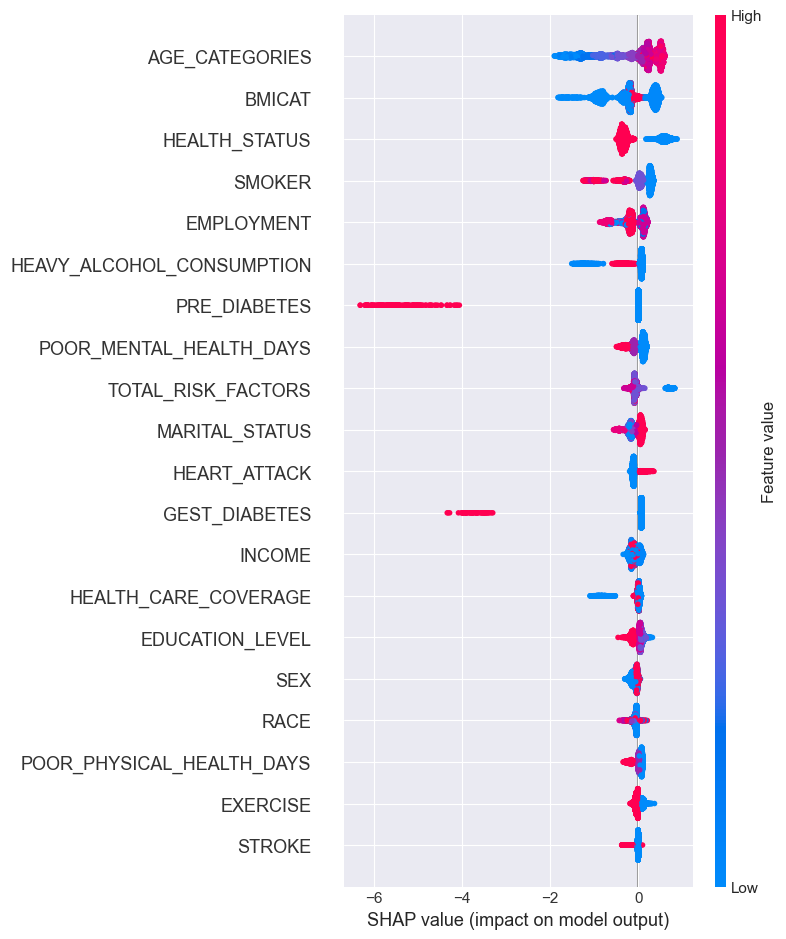

In [30]:
# FAST TREE SHAP (NO PERMUTATION)
explainer = shap.TreeExplainer(model, data=background, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_sample)

# GLOBAL FEATURE IMPORTANCE
shap.summary_plot(shap_values, X_test_sample)

### Interpretation

The summary plot highlights the most influential predictors of diabetes risk and illustrates how higher or lower feature values shift predictions toward increased or decreased risk.

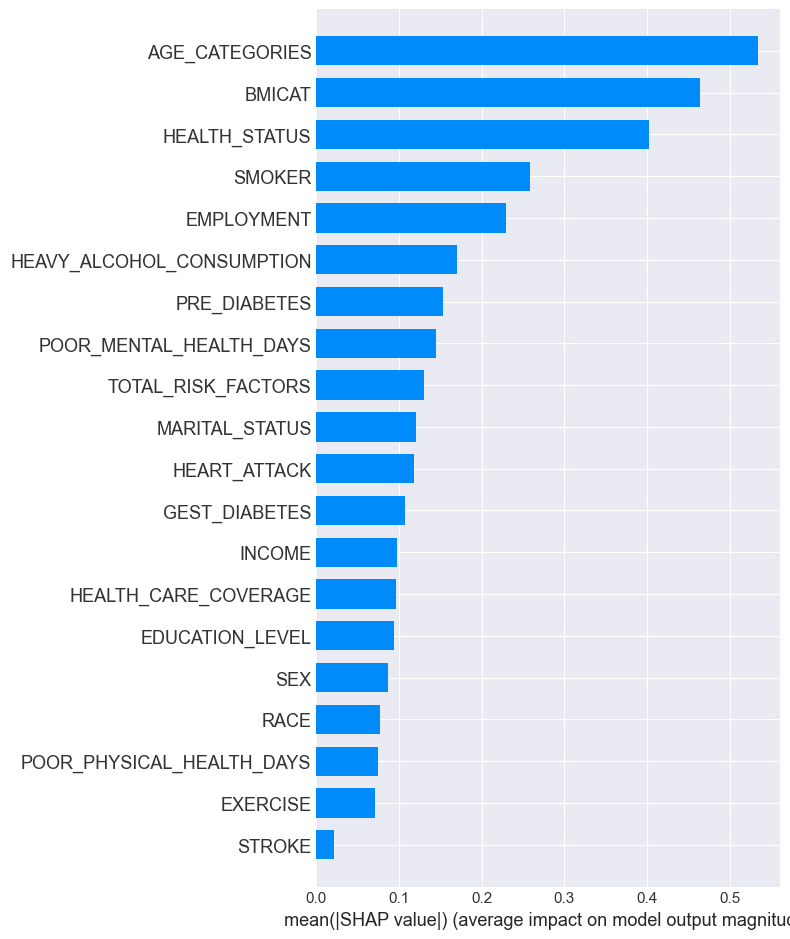

In [31]:
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")

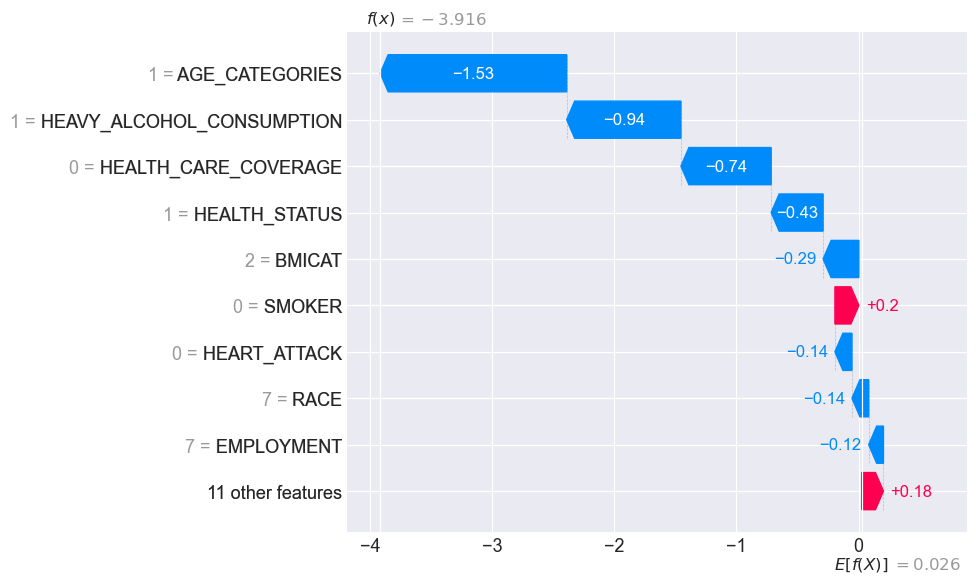

In [32]:
shap.plots.waterfall(shap.Explanation(values=shap_values[0], base_values=explainer.expected_value, data=X_test_sample.iloc[0], feature_names=X_test_sample.columns))

The SHAP visualizations create a multi-level risk assessment which shows diabetes risk. The risk assessment shows that age, BMI category and overall health status are the main risk factors which confirm that aging and metabolic health serve as the primary structural elements. The combination of smoking and heavy alcohol use together with pre-diabetes and gestational diabetes as previous medical conditions creates higher risk, while exercise acts as a protective behavior which lowers risk. Socioeconomic factors provide contextual information, but their effect remains less significant than other factors.

The importance ranking demonstrates this pattern because biological and metabolic factors serve as the most powerful predictive elements while lifestyle and social determinants create risk patterns which exist around them.

The waterfall plot shows that individual risk assessment requires cumulative risk assessment because protective factors (e.g., younger age category, absence of major health events, health coverage) can eliminate minor risk factors to produce overall reduced predicted risk.

Key takeaway: Diabetes risk occurs due to aging and obesity which get worsened through lifestyle choices and past metabolic disorders, while individual outcomes exist because people show different responses to various risk factors and protective elements.

## 4.12 SHAP Interaction Analysis (RQ3)

### Interaction Insight

Dependence plots illustrate how specific predictors influence diabetes risk and how their effects may vary based on related factors.

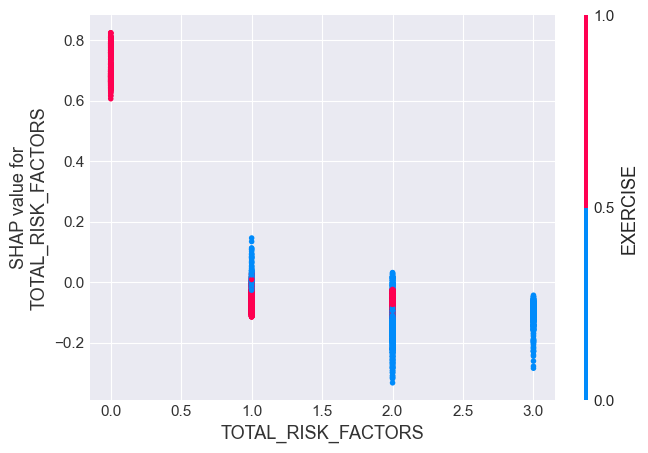

In [33]:
shap.dependence_plot("TOTAL_RISK_FACTORS", shap_values, X_test_sample)

Diabetes risk rises with increasing total risk factors according to the plot. The multiple risk factor group has stronger negative SHAP values which indicates they face greater predicted risk.

Exercise moderates this effect: those who exercise tend to have less severe risk contributions because physical activity helps them control the effects of their combined risks.

Diabetes risk increases with each additional risk factor yet exercise has been shown to decrease risk severity.

## 4.12 Predictor Stability Over Time (RQ4)

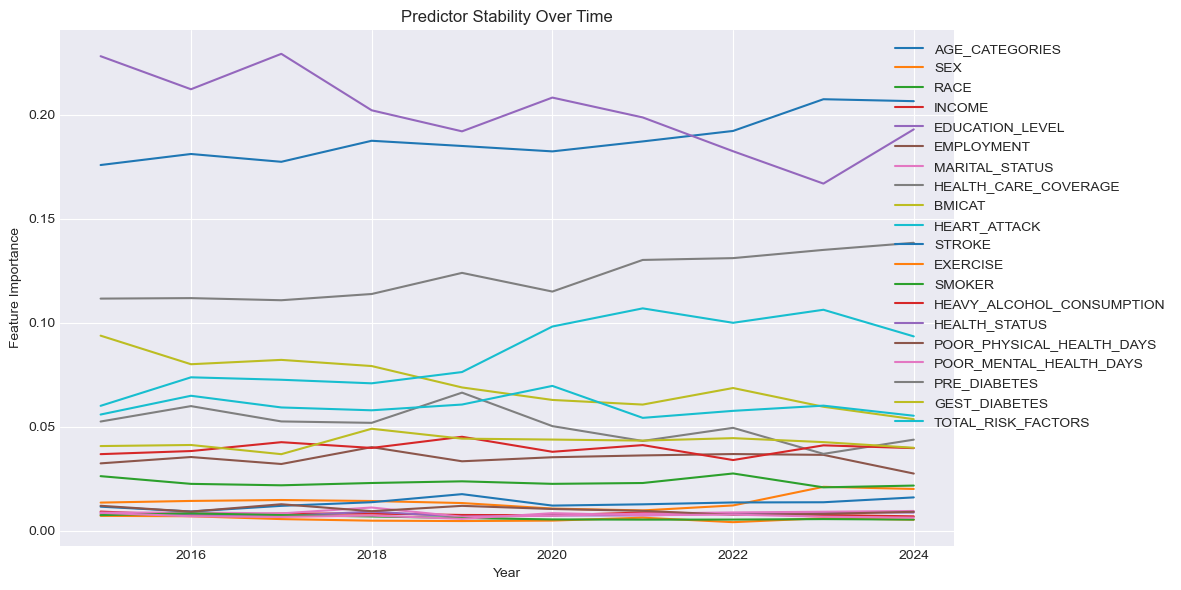

In [34]:
df_raw["YEAR"] = df_raw["YEAR"].astype(int)

years = sorted(df_raw["YEAR"].unique())

year_importance = []

for year in years:

    subset = df_raw[df_raw["YEAR"] == year]

    # skip years with too few samples
    if len(subset) < 500:
        continue

    X_year = subset[features].astype("float32")
    y_year = subset[target]

    # ⭐ fresh model without early stopping
    yearly_model = XGBClassifier(
        tree_method="gpu_hist",
        predictor="gpu_predictor",
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    )

    yearly_model.fit(X_year, y_year)

    # store absolute importance
    year_importance.append(np.abs(yearly_model.feature_importances_))

# build dataframe
importance_df = pd.DataFrame(year_importance, columns=features, index=years[:len(year_importance)])

# --------------------------------------------------
# Plot Predictor Stability Over Time
# --------------------------------------------------
plt.figure(figsize=(12,6))
importance_df.plot(ax=plt.gca())

plt.title("Predictor Stability Over Time")
plt.xlabel("Year")
plt.ylabel("Feature Importance")
plt.legend(loc="upper right", bbox_to_anchor=(1.25,1))
plt.tight_layout()
plt.show()

The study demonstrates that diabetes risk factors have maintained their primary consistency throughout the years. The strongest diabetes risk indicators include age, education level, health status and BMI category which indicate that structural and metabolic factors have maintained their influence on diabetes.

The healthcare coverage and total risk factor levels, which show a gradual increase in importance, demonstrate that healthcare access and total health burden have become more important. The income and physical health indicators show small changes, while the sex and race and stroke indicators remain low and stable.

The study results show that diabetes risk factors stay constant with time, as aging and metabolic health remain important, while healthcare access and total risk burden have become more significant.

## Modeling Outcome

The predictive model demonstrates the ability to identify individuals at elevated risk for diabetes using demographic, behavioral and health-related indicators. Interpretability analysis confirms that key predictors align with established epidemiological evidence, supporting the validity and practical relevance of the modeling approach.